|<h2>Course:</h2>|<h1><a href="https://udemy.com/course/dullms_x/?couponCode=202508" target="_blank">A deep understanding of AI language model mechanisms</a></h1>|
|-|:-:|
|<h2>Part 1:</h2>|<h1>Tokenizations and embeddings<h1>|
|<h2>Section:</h2>|<h1>Embedding spaces<h1>|
|<h2>Lecture:</h2>|<h1><b>Exploring GPT2 and BERT embeddings<b></h1>|

<br>

<h5><b>Teacher:</b> Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h5>
<h5><b>Course URL:</b> <a href="https://udemy.com/course/dullms_x/?couponCode=202508" target="_blank">udemy.com/course/dullms_x/?couponCode=202508</a></h5>
<i>Using the code without the course may lead to confusion or errors.</i>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# higher-res plots
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# Import GPT-2 and BERT models and tokenizers

In [2]:
from transformers import GPT2Model,GPT2Tokenizer
gpt2 = GPT2Model.from_pretrained('gpt2')
tokenizerG = GPT2Tokenizer.from_pretrained('gpt2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [3]:
from transformers import BertTokenizer, BertModel
tokenizerB = BertTokenizer.from_pretrained('bert-base-uncased')
bert = BertModel.from_pretrained('bert-base-uncased')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

In [4]:
# check out the model
print(gpt2)

GPT2Model(
  (wte): Embedding(50257, 768)
  (wpe): Embedding(1024, 768)
  (drop): Dropout(p=0.1, inplace=False)
  (h): ModuleList(
    (0-11): 12 x GPT2Block(
      (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (attn): GPT2Attention(
        (c_attn): Conv1D(nf=2304, nx=768)
        (c_proj): Conv1D(nf=768, nx=768)
        (attn_dropout): Dropout(p=0.1, inplace=False)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
      (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (mlp): GPT2MLP(
        (c_fc): Conv1D(nf=3072, nx=768)
        (c_proj): Conv1D(nf=768, nx=3072)
        (act): NewGELUActivation()
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
)


In [5]:
# check out the model
print(bert)

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False

# How long are the tokens?

In [6]:
print(f'BERT has {tokenizerB.vocab_size:,} tokens.')
print(f'GPT2 has {tokenizerG.vocab_size:,} tokens.')

BERT has 30,522 tokens.
GPT2 has 50,257 tokens.


In [7]:
# GPT: get all individual lengths
token_lengths = np.zeros(tokenizerG.vocab_size,dtype=int)
for idx,word in enumerate( tokenizerG.encoder.keys() ):
  token_lengths[idx] = len(word)

# unique values and counts for bar plot
uniqueLengthsG,tokenCountG = np.unique(token_lengths,return_counts=True)



# BERT: get all individual lengths
token_lengths = np.zeros(tokenizerB.vocab_size,dtype=int)
for idx,word in enumerate( tokenizerB.get_vocab().keys() ): # note difference from GPT!
  token_lengths[idx] = len(word)

# unique values and counts for bar plot
uniqueLengthsB,tokenCountB = np.unique(token_lengths,return_counts=True)

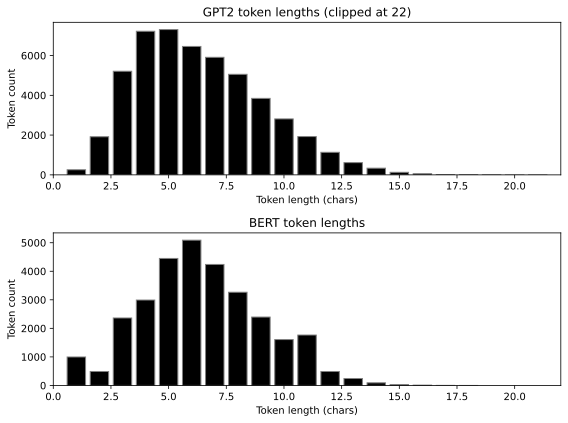

In [8]:
# draw the barplot!
_,axs = plt.subplots(2,1,figsize=(8,6))
axs[0].bar(uniqueLengthsG,tokenCountG,color='k',edgecolor='gray')
axs[0].set(xlabel='Token length (chars)',ylabel='Token count',title='GPT2 token lengths (clipped at 22)',
           xlim=[0,22])

axs[1].bar(uniqueLengthsB,tokenCountB,color='k',edgecolor='gray')
axs[1].set(xlabel='Token length (chars)',ylabel='Token count',title='BERT token lengths',
           xlim=[0,22])

plt.tight_layout()
plt.show()

# Extract and visualize the embeddings matrices

In [9]:
# get the Word Token Embeddings matrix
embeddingsG = gpt2.wte.weight.detach().numpy()

# get the word token embeddings matrix (note the different variable names compared to GPT2!
embeddingsB = bert.embeddings.word_embeddings.weight.detach().numpy()

# print their sizes
print(f'BERT embedding matrix is of size {embeddingsB.shape}.')
print(f'GPT2 embedding matrix is of size {embeddingsG.shape}.')

BERT embedding matrix is of size (30522, 768).
GPT2 embedding matrix is of size (50257, 768).


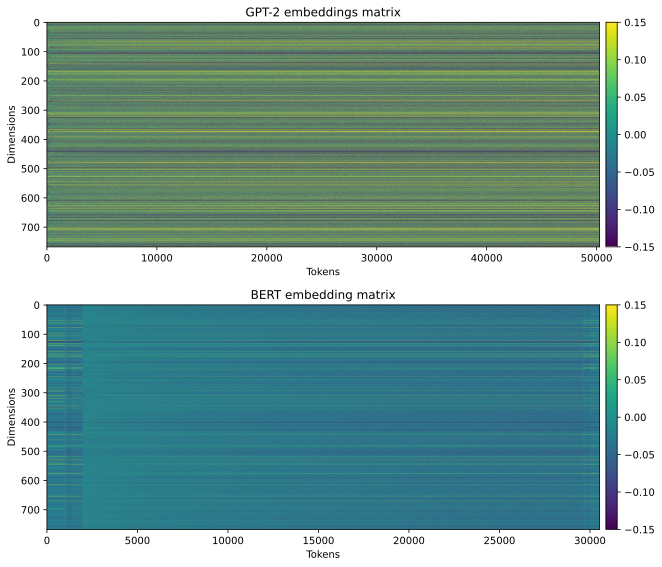

In [10]:
fig,axs = plt.subplots(2,1,figsize=(10,8))

# GPT embeddings
h = axs[0].imshow(embeddingsG.T,aspect='auto',vmin=-.15,vmax=.15)
axs[0].set(xlabel='Tokens',ylabel='Dimensions',title='GPT-2 embeddings matrix')
fig.colorbar(h,ax=axs[0],pad=.01)

# BERT embeddings
h = axs[1].imshow(embeddingsB.T,aspect='auto',vmin=-.15,vmax=.15)
axs[1].set(xlabel='Tokens',ylabel='Dimensions',title='BERT embedding matrix')
fig.colorbar(h,ax=axs[1],pad=.01)

plt.tight_layout()
plt.show()

# Comparing the same token index

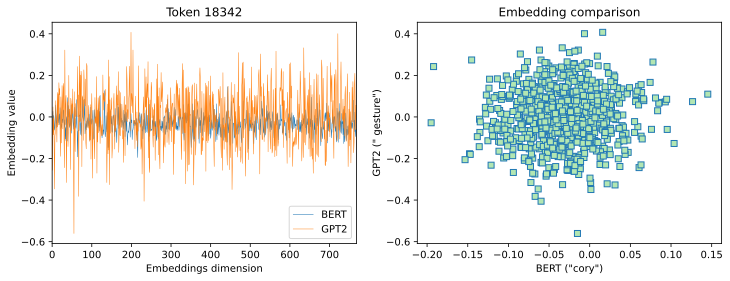

In [11]:
# pick a random token index
ridx = np.random.randint(10000,20000)

_,axs = plt.subplots(1,2,figsize=(12,4))

axs[0].plot(embeddingsB[ridx,:],label='BERT',linewidth=.5)
axs[0].plot(embeddingsG[ridx,:],label='GPT2',linewidth=.5)
axs[0].legend()
axs[0].set(xlabel='Embeddings dimension',ylabel='Embedding value',xlim=[0,embeddingsB.shape[1]],title=f'Token {ridx}')

axs[1].plot(embeddingsB[ridx,:],embeddingsG[ridx,:],'s',markerfacecolor=[.7,.9,.7])
axs[1].set(xlabel=f'BERT ("{tokenizerB.decode(ridx)}")',ylabel=f'GPT2 ("{tokenizerG.decode(ridx)}")',
           title='Embedding comparison')

plt.show()

In [12]:
# how about the same word?
token = 'the'
token_idxB = tokenizerB.encode(token)[1]
token_idxG = tokenizerG.encode(token)[0]

print(f'BERT: "{token}" is index {token_idxB}')
print(f'GPT2: "{token}" is index {token_idxG}')

BERT: "the" is index 1996
GPT2: "the" is index 1169


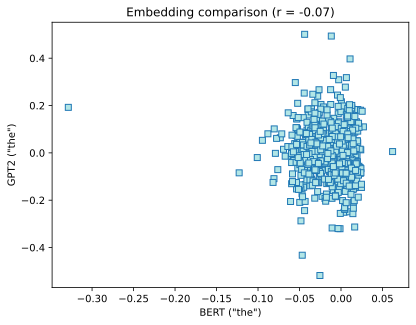

In [13]:
# their correlation
corr = np.corrcoef(embeddingsB[token_idxB,:],embeddingsG[token_idxG,:])

plt.plot(embeddingsB[token_idxB,:],embeddingsG[token_idxG,:],'s',markerfacecolor=[.7,.9,.9])
plt.gca().set(xlabel=f'BERT ("{tokenizerB.decode(token_idxB)}")',ylabel=f'GPT2 ("{tokenizerG.decode(token_idxG)}")',
           title=f'Embedding comparison (r = {corr[0,1]:.2f})')

plt.show()

# Distributions of embeddings characteristics

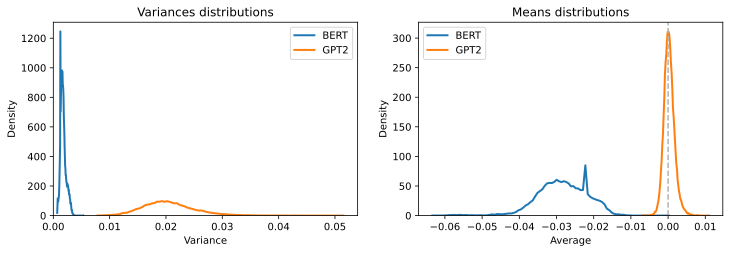

In [18]:
_,axs = plt.subplots(1,2,figsize=(12,3.5))

# compare the embeddings variances
yB,xB = np.histogram(embeddingsB.var(axis=1),bins=100,density=True)
yG,xG = np.histogram(embeddingsG.var(axis=1),bins=100,density=True)

axs[0].plot(xB[:-1],yB,linewidth=2,label='BERT')
axs[0].plot(xG[:-1],yG,linewidth=2,label='GPT2')
axs[0].set(xlabel='Variance',ylabel='Density',xlim=[0,None],ylim=[0,None],title='Variances distributions')
axs[0].legend()

# compare the embeddings means
yB,xB = np.histogram(embeddingsB.mean(axis=1),bins=100,density=True)
yG,xG = np.histogram(embeddingsG.mean(axis=1),bins=100,density=True)

axs[1].plot(xB[:-1],yB,linewidth=2,label='BERT')
axs[1].plot(xG[:-1],yG,linewidth=2,label='GPT2')
axs[1].axvline(0,color=[.7,.7,.7],linestyle='--')
axs[1].set(xlabel='Average',ylabel='Density',ylim=[0,None],title='Means distributions')
axs[1].legend()


plt.show()